# Day 2 : Cross-Validation 

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

### Table of Contents:

1. [Introduction](#intro)
2. [Section 1 — Types of Cross-Validation: How It Works & Functionality](#section1)
3. [Section 2 — Implementation](#section2)
4. [Section 3 — Hands-On Lab](#section3)
5. [References](#refs)


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="intro"></a>
# Introduction

In [Day 1 notebook](https://github.com/thimarArda/BinX_AI_-_ML_Training/blob/main/Week4_Evaluating_and_Tuning/Day1_Train_Validation_Test_Split/Train_Validation_Test_Splits.ipynb) , we introduced the idea of splitting our data into training, validation, and test sets so that we can evaluate our model during the development process without using the test set for tuning. The validation set gives us a separate portion of data that we can use to compare different models and hyperparameters before making our final evaluation on the test set.

However, using a single validation split also has a limitation. The results we get can depend heavily on which samples happened to be placed in the validation set. If that particular subset is easier, harder, or simply different from the rest of the data, the model may appear to perform better or worse than it actually does. This means that our model selection and hyperparameter tuning can sometimes be influenced by the randomness of one particular split rather than the actual generalization ability of the model.

In this notebook we are introducing a solution to that, **Cross-Validation (CV)**. Which divides the training data into multiple subsets, called **folds**, and repeatedly trains and validates the model using different folds. Each fold gets a chance to act as the validation set while the remaining folds are used for training.



<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section1"></a>
# Section 1 : Types of Cross-Validation

### Why Cross validation over one split validation ?
> A single validation split gives exactly one performance number. That number is a *sample* — and like any
sample, it has variance. K-fold cross-validation replaces that one lucky-or-unlucky split with **k**
different splits, trains the model **k** times, and averages the results. Every data point gets used for
validation exactly once and for training k−1 times, so no single split can dominate the result, and no
data point is "wasted" by permanently sitting in a held-out set during development.

## 1.1  K-Fold Cross-Validation

### How Does K-Fold CV work?

1. **The training data** is divided into **k** equal-sized parts called **folds**.
2. The model is then trained and evaluated **k** times.
3.  On each round, one fold is held out as the validation set, and the remaining k−1 folds are used for training.

This means every fold gets to "be" the validation set exactly once.

**Example with k = 5:**

| Round | Trains On | Validates On |
|-------|--------------------|---------------|
| 1 | Folds 2, 3, 4, 5 | Fold 1 |
| 2 | Folds 1, 3, 4, 5 | Fold 2 |
| 3 | Folds 1, 2, 4, 5 | Fold 3 |
| 4 | Folds 1, 2, 3, 5 | Fold 4 |
| 5 | Folds 1, 2, 3, 4 | Fold 5 |

The final cross-validated score is the **mean** of the k individual fold scores, and the **standard
deviation** tells us how much that score varies across folds:

$$
\overline{CV} \;=\; \frac{1}{k}\sum_{i=1}^{k} s_i
$$

$$
\sigma_{CV} \;=\; \sqrt{\frac{1}{k}\sum_{i=1}^{k}\left(s_i - \overline{CV}\right)^2}
$$

**where :** $s_i$ is the score obtained on fold $i$.

**How to read the two numbers together:**
- **High mean, low std** → a model I can trust; performance is consistently good across different slices of data.
- **High mean, high std** → the model might just be getting lucky on some folds; the "good" score is not reliable.

**Note :** `k = 5` and `k = 10` are the most common choices in practice, in a lot of times, the training dataset might have classes imbalance which might lead to bad splitting if the k values was low (one class takes most of the splits), so a k value between 5 and 10 is often recomended to balance the selection of the validation split from all the classes in the dataset.


------------

## 1.2 Stratified K-Fold for Classification

Stratified K-Fold Cross Validation is a technique used for evaluating a model. It is particularly useful for classification problems in which the class labels are not evenly distributed i.e data is imbalanced. It is an enhanced version of K-Fold Cross Validation. 

**Stratified k-fold**  preserves the *original* class balance in every single fold.

### How Stratified K-Fold solves the impalanced distribution

<a id="example"></a>
#### Example : 
If the full dataset is 90% class 0 / 10% class 1, every fold will also be roughly 90% / 10%. Scikit-learn actually
applies stratified k-fold **automatically** whenever `cross_val_score` (or `GridSearchCV`) is used with a
classifier — but it's worth knowing it's happening, and being able to do it explicitly.

>  <div style="text-align: center;"> <img src="stratified_cv.png" alt="Illustration of Stratified K-Fold for Classification " width="400" > </div>
>

**Stratified K-Fold** works similarly to regular K-Fold, but with one important difference: when creating the folds, it also looks at the **target labels** and tries to preserve the same class proportions in every fold.

Using the previous example:

```text
Original dataset:
900 Class 0
100 Class 1

        ↓ Stratified K-Fold (k = 5)

Fold 1 → 180 Class 0 + 20 Class 1
Fold 2 → 180 Class 0 + 20 Class 1
Fold 3 → 180 Class 0 + 20 Class 1
Fold 4 → 180 Class 0 + 20 Class 1
Fold 5 → 180 Class 0 + 20 Class 1
```

Now every fold is approximately **90% Class 0 and 10% Class 1**, just like the original dataset.

The cross-validation process itself is still the same:

| Round | Trains On | Validates On |
|------|-----------|--------------|
| 1 | Folds 2, 3, 4, 5 | Fold 1 |
| 2 | Folds 1, 3, 4, 5 | Fold 2 |
| 3 | Folds 1, 2, 4, 5 | Fold 3 |
| 4 | Folds 1, 2, 3, 5 | Fold 4 |
| 5 | Folds 1, 2, 3, 4 | Fold 5 |

**The difference is in how the folds were created.**

------

### Stratified K-Fold in Scikit-Learn

For classification, Scikit-learn provides `StratifiedKFold` explicitly:

```python
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
```

Then the folds can be used to train and validate the model while maintaining the class proportions:

```python
for train_index, val_index in skf.split(X, y):
    X_train_fold = X.iloc[train_index]
    X_val_fold = X.iloc[val_index]

    y_train_fold = y.iloc[train_index]
    y_val_fold = y.iloc[val_index]

    model.fit(X_train_fold, y_train_fold)
    predictions = model.predict(X_val_fold)
```

--------

## 1.3 K-Fold vs Stratified K-Fold

The easiest way to remember the difference is:

| | K-Fold | Stratified K-Fold |
|---|---|---|
| Divides data into k folds | ✓ | ✓ |
| Each fold becomes validation once | ✓ | ✓ |
| Trains the model k times | ✓ | ✓ |
| Calculates scores across folds | ✓ | ✓ |
| Considers the target class when creating folds | ✗ | ✓ |
| Attempts to preserve class proportions | ✗ | ✓ |
| Recommended for classification | Sometimes | **Usually preferred** |

So, if I have a classification dataset with classes that are not perfectly balanced, **Stratified K-Fold is generally a better choice than ordinary K-Fold** because each validation fold remains representative of the original class distribution.

### What Happens If the Classes Are Balanced?

If the classes are already well balanced, ordinary K-Fold may not cause a major problem, especially with a sufficiently large dataset. However, stratification is still commonly preferred for classification because it gives more control over the class distribution in each fold.

For example, with:

```text
Class 0 → 50%
Class 1 → 50%
```

Stratified K-Fold will try to keep every fold close to:

```text
50% Class 0
50% Class 1
```

This makes the validation sets more consistent with the original dataset.

### Why Is This Especially Important for Imbalanced Data?

Consider a medical classification problem where:

```text
95% → Negative
5%  → Positive
```

The positive class may be the class we care about most.

If ordinary K-Fold creates a validation fold containing very few positive examples, the model's ability to detect that class can be difficult to evaluate reliably. For example, a model could achieve a high accuracy simply because most samples are negative, while its ability to identify positive cases is actually poor.

Stratification does not fix the **class imbalance itself**. It only makes sure that the imbalance is represented consistently across the folds.

This distinction is important:

> **Stratified K-Fold does not balance the dataset. It preserves the existing class distribution across the folds.**

So if the original dataset is 95% negative and 5% positive, stratification does **not** turn it into 50/50. Instead, it tries to make each fold approximately 95% negative and 5% positive.

------------------

## 1.4 Bonus - Other Types of Cross Validation



| Variant | What It Does | When To Use It |
|---|---|---|
| **Leave-One-Out (LOOCV)** | Each fold is a single data point (k = n) | Very small datasets, where every data point is precious |
| **Repeated K-Fold** | Runs k-fold multiple times with different random splits, then averages | When I want an even more stable estimate and can afford the extra compute |
| **Group K-Fold** | Keeps all rows from the same "group" (e.g., same patient/user) in the same fold | When rows aren't independent — prevents leakage across related rows |
| **TimeSeriesSplit** | Folds respect chronological order — never trains on the future to predict the past | Time-series / forecasting problems |


>  <div style="text-align: center;"> <img src="CVs.png" alt="Different types of CV  " width="400" > </div>

**Note :** Not all the listed types are illustrated in this picture so [read more about the other CV techniques here!](https://www.geeksforgeeks.org/machine-learning/cross-validation-machine-learning/)



<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section2"></a>
# Section 2 : Implementing K-fold validation with code

> In this section, the implementation will cover the K-Fold and the Stratified K-Fold only
>
> 

## 1. Uploading and inspecting the dataset

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
df.head()

X = df.drop("target", axis=1) # features: everything except the target
y = df["target"]
print(X)
print()
print(y)



Shape: (1025, 14)
      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  
0         2   2     3  
1        

### Checking for Class impalance

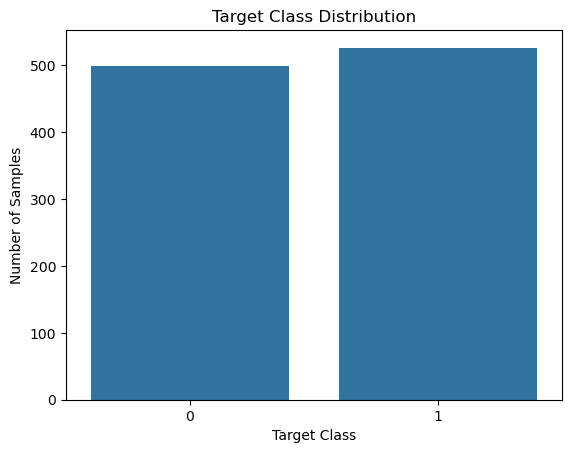

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=y)

plt.title("Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")
plt.show()

## 2. Split the data into 80% training and 20% testing

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Full training data shape:", X_train.shape)    # Display the dimensions of the training images
print("Full training labels shape:", y_train.shape)  # Display the dimensions of the training labels
print("Test data shape:", X_test.shape)                   # Display the dimensions of the test images
print("Test labels shape:", y_test.shape)    

Full training data shape: (820, 13)
Full training labels shape: (820,)
Test data shape: (205, 13)
Test labels shape: (205,)


### Checking for Class impalance in the training set

In [6]:
print("Training class counts:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training class counts:
target
1    423
0    397
Name: count, dtype: int64

Training class percentages:
target
1    51.59
0    48.41
Name: proportion, dtype: float64


> The classes are balanced, so we can either use the plain K-Fold or the Stratified K-Fold

## 3. Train a Machine Learning Model and interpret it's performance

using `.score()` to measure performance on the test set and return accuracy.

`.score()` doesn't always return accurecy, but in logetic regression it does 
```python
LogisticRegression.score()
→ returns  accuracy
```

In [16]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression
logistic_model = LogisticRegression(max_iter=4000)
logistic_model.fit(X_train, y_train)
logistic_model.score(X_test, y_test)

0.7951219512195122

## 4. K-Fold Cross-Validation with `cross_val_score` 

```python
cross_val_score(model, X_train, y_train, cv=5, scoring="f1")
It tells cross_val_score:
"For each fold, evaluate the model using the F1-score instead of accuracy."
```

**Note:** we can use other evaluation metrecies like `accurecy` in this example

In [22]:
from sklearn.model_selection import cross_val_score
# scores = cross_val_score(logistic_model, X_train, y_train, cv=5, scoring="f1")
scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Per-fold accuracy scores:", np.round(scores, 4))    # Or:  print(scores) # one score per fold
print("Mean accurecy", scores.mean()) # the reliable average
print( "Standard deviation :" , scores.std()) # how much the score varies across folds

Per-fold accuracy scores: [0.8293 0.8476 0.9024 0.8659 0.8049]
Mean Accurecy 0.85
Standard deviation : 0.033084536503050085


#### results :

- **Mean :** 0.85
- **Strandard Devision :** 0.033084536503050085
- **High mean, low std** → a model I can trust; performance is consistently good across different slices of data.

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section3"></a>
# Section 3 : Hands-on Lap

#### Note:
This Section is referencing [Week3_Spervised_Learning:](https://github.com/thimarArda/BinX_AI_-_ML_Training/tree/main/Week3_Spervised_Learning), which contains all the discribtions on the methods and datasets that arent presented in this notebook. It also uses previous model from [Week4_Day1:Train_Validation_Test_Split](https://github.com/thimarArda/BinX_AI_-_ML_Training/tree/main/Week4_Evaluating_and_Tuning/Day1_Train_Validation_Test_Split)

## Step 1: Take a Week 3 model and evaluate it with 5-fold cross-validation using cross_val_score


### First we upload our dataset

In [ ]:
# First we upload our dataset
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
df.head()

X = df.drop("target", axis=1) # features: everything except the target
y = df["target"]
print(X)
print()
print(y)



### Splitting the data into 80% training and 20% testing

In [ ]:
# Splitting the data into 80% training and 20% testing 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Training Logetic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression
logistic_model = LogisticRegression(max_iter=4000)
logistic_model.fit(X_train, y_train)
logistic_model.score(X_test, y_test)

0.7951219512195122

### Evaluate the model with 5-fold cross-validation using cross_val_score

In [ ]:
from sklearn.model_selection import cross_val_score
# scores = cross_val_score(logistic_model, X_train, y_train, cv=5, scoring="f1")
scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Per-fold accuracy scores:", np.round(scores, 4))    # Or:  print(scores) # one score per fold
print("Mean accurecy", scores.mean()) # the reliable average
print( "Standard deviation :" , scores.std()) # how much the score varies across folds

## Step 2: Report the mean and standard deviation of the scores across folds.

### Output :

```text
Per-fold accuracy scores: [0.8293 0.8476 0.9024 0.8659 0.8049]
Mean Accurecy 0.85
Standard deviation : 0.033084536503050085
```

### Analysis:


The model achieved a mean accuracy of 85% across the five folds. The standard deviation is approximately  3.31% points, which shows how much the accuracy varies between the different folds.

Since the standard deviation is small compared to the mean accuracy, the model's performance is consistent across the different folds and it doesn't  depend heavily on one particular split of the data.

----------

## Step 3: Compare the cross-validated estimate to the single-split score from Day 1 and explain any difference.


In [Day 1 notebook](https://github.com/thimarArda/BinX_AI_-_ML_Training/blob/main/Week4_Evaluating_and_Tuning/Day1_Train_Validation_Test_Split/Train_Validation_Test_Splits.ipynb) we used the training/validation/test split  technique and on 5 classification models. **Using accurecy as a performance measure.** 

But we used the `Breast Cancer Wisconsin ` dataset from scikit-learn. Here we are implementing the same model with the validation technique on the `Heart Disease` dataset.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score

# Logistic Regression
logistic_model = LogisticRegression(max_iter=4000)
logistic_model.fit(X_train, y_train)


# 1) hold out 20% as the final test set
X_temp, X_test, y_temp, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42)

# 2) split the rest into train (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)



logistic_val_pred = logistic_model.predict(X_val)
print("Logistic Regression validation accurecy:", accuracy_score(y_val, logistic_val_pred))

Logistic Regression validation accurecy: 0.8780487804878049


<a id="accurecy"></a>
### Comparing Between the two accurecies

| Model | Validation Method | Validation accurecy |
|-------|--------------------|---------------|
| Logestic Regression | training/validation/test split | 87.8% |
| Logestic Regression | 5-fold cross-validation | 85% |


### Comparison and Interpretation

The Logistic Regression model achieved an accuracy of **87.8%** using the train/validation/test split, while the 5-fold cross-validation produced a mean accuracy of **85%**, with a standard deviation of approximately **3.31%**.

The difference is expected because the single-split approach evaluates the model on only one particular subset of data. That subset may happen to be easier for the model to classify, resulting in a slightly higher accuracy. In contrast, 5-fold cross-validation evaluates the model on five different validation subsets and averages their scores, making the estimate less dependent on one particular split.

In this case, the cross-validation scores ranged from **80.49% to 90.24%**, so the 87.8% score from the single split falls within the range of the cross-validation results. Therefore, the lower cross-validated accuracy does not indicate that the model  gives a more stable view of its performance across different subsets of the training data.

----------



### Comparing Between other metrecies (using F1 score)
For a more complete evaluation, accuracy can be considered together with metrics such as **precision, recall, F1-score, and ROC-AUC**, especially when the consequences of false positives and false negatives are important.

```python
scoring="accuracy"
scoring="precision"
scoring="recall"
scoring="f1"
scoring="roc_auc"
```

In [26]:
from sklearn.metrics import f1_score
logistic_val_pred = logistic_model.predict(X_val)
print("Logistic Regression validation accurecy:", f1_score(y_val, logistic_val_pred))

print("---------------------------------------------")

scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Per-fold f1 scores:", np.round(scores, 4))    # Or:  print(scores) # one score per fold
print("Mean f1", scores.mean()) # the reliable average
print( "Standard deviation :" , scores.std()) # how much the score varies across folds

Logistic Regression validation accurecy: 0.8863636363636364
---------------------------------------------
Per-fold f1 scores: [0.8732 0.9118 0.869  0.8175 0.8406]
Mean f1 0.8624135236127121
Standard deviation : 0.03189974724512511


| Model | Validation Method | F1 Score |
|-------|--------------------|---------------|
| Logestic Regression | training/validation/test split | 88.6% |
| Logestic Regression | 5-fold cross-validation | 86.2% |

### Comparison and Interpretation
Same logic applied as the [accurecy results](#accurecy), the 88.6% score from the single split may have been somewhat optimistic, while the 86.2% cross-validated score provides a more stable estimate of the model's F1 performance across different subsets of the training data.

--------------

## Step 4: For a classification task, confirm stratified folds are used and explain why that matters here

In real-world classification datasets, the target classes are not always perfectly balanced. We may encounter a small imbalance between the classes, or in some cases, a significant difference where one class has many more samples than another.

When using a traditional K-Fold split, the folds are created without considering the target class labels. This means that the proportion of each class can vary between folds. As a result, one validation fold might contain relatively more samples from one class and fewer from another. This can make the evaluation score more dependent on the particular samples that ended up in each fold.

**Stratified K-Fold is more suitable for classification because it considers the target labels when creating the folds.** It tries to maintain approximately the same class proportions in every fold as in the original training data.

[An example on this was presented in section 2](#example)

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="refs"></a>
# References

- Read more about Cross Validation in Machine Learning : https://www.geeksforgeeks.org/machine-learning/cross-validation-machine-learning/
-  Read more about K-fold Cross Validation : https://www.geeksforgeeks.org/r-language/k-fold-cross-validation-in-r-programming/
- For more code practices on Cross-Validation : https://github.com/codebasics/py/blob/master/ML/12_KFold_Cross_Validation/12_k_fold.ipynb